# K-Nearest Neighbors from Scratch

K-Nearest Neighbors classifies a point by looking at the $k$ closest points in the training data
and taking a majority vote among their labels.

The distance from the new point $x$ to a stored point $x_i$ is the Euclidean distance

$$d(x, x_i) = \lVert x - x_i \rVert_2 = \sqrt{\sum_{d=1}^{D} (x_d - x_{i,d})^2}$$

Sorting all $n$ training points by that distance and keeping the first $k$ gives the neighbour set
$N_k(x)$. The prediction is whichever label occurs most often inside it:

$$\hat{y} = \arg\max_{c} \sum_{i \in N_k(x)} \mathbb{1}[\, y_i = c \,]$$

where $\mathbb{1}[\cdot]$ is 1 when the condition holds and 0 otherwise. The share of the vote won
by that label is reported as a confidence:

$$\text{confidence} = \frac{1}{k} \max_{c} \sum_{i \in N_k(x)} \mathbb{1}[\, y_i = c \,]$$

There is no training step. Nothing is fitted and no parameters are learned - the training data
itself is the model. All of the work happens at prediction time, and the cost of a single
prediction is $O(nD)$ to measure every distance plus $O(n \log n)$ to sort them.

This notebook runs it on the Breast Cancer Wisconsin dataset, classifying tumour samples as
benign or malignant.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from collections import Counter
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

benign_color, malignant_color = '#2a78d6', '#eb6834'

## Loading the data

`fetch_ucirepo(id=15)` downloads the dataset: 699 tumour samples with 9 measurements each, every
one recorded on a scale of 1 to 10. The label is `2` for benign and `4` for malignant.

16 rows have a missing `Bare_nuclei` value. The cell builds a `keep` mask with `isna` and drops
those rows, leaving 683.

Every feature already shares the same 1 to 10 scale, so no scaling is needed here. That matters
more for this algorithm than for most, because every feature enters the distance through the same
sum:

$$d(x, x_i)^2 = \sum_{d=1}^{D} (x_d - x_{i,d})^2$$

A column measured in thousands would contribute terms thousands of times larger than one measured
in single digits, so it would decide the ordering on its own and the other eight would barely
count.

In [2]:
cancer = fetch_ucirepo(id=15)

features = cancer.data.features
targets = cancer.data.targets

# 16 rows have a missing Bare_nuclei value
keep = ~features.isna().any(axis=1)

X = features[keep].values.astype(float)
y = targets[keep].values.ravel()
feature_names = list(features.columns)

print('samples:', X.shape)
print('features:', feature_names)
print('benign (2):   ', (y == 2).sum())
print('malignant (4):', (y == 4).sum())

samples: (683, 9)
features: ['Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion', 'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses']
benign (2):    444
malignant (4): 239


## Splitting into train and test

The data is shuffled with a seeded generator so the split is repeatable, then cut 80/20.

Both halves are stored as dictionaries keyed by the label, so `train_set[2]` is a list of every
benign sample and `train_set[4]` is every malignant one. Holding the data this way means the
voting function can loop over the groups directly and read the label off the key.

In [3]:
rng = np.random.default_rng(0)
order = rng.permutation(len(X))
split = int(0.8 * len(X))

train_set = {2: [], 4: []}
test_set = {2: [], 4: []}

for i in order[:split]:
    train_set[y[i]].append(X[i])

for i in order[split:]:
    test_set[y[i]].append(X[i])

print('train:', {g: len(train_set[g]) for g in train_set})
print('test: ', {g: len(test_set[g]) for g in test_set})

train: {2: 350, 4: 196}
test:  {2: 94, 4: 43}


## The k_nearest_neighbors function

The function takes the training data, one point to classify, and `k`.

- it loops over both groups and every sample in them, measuring the distance from that sample to
  the point with `np.linalg.norm`
- each distance is appended alongside the group it came from, as `[distance, group]`
- `sorted(distances)[:k]` sorts by distance, because that is the first element of each pair, and
  keeps the `k` closest
- `Counter(votes).most_common(1)` returns the label that appears most often among those `k`

`confidence` is how many of the `k` votes went to the winner, divided by `k`. A result of 5 out of
5 means every neighbour agreed, while 3 out of 5 means the point sits near a boundary. This is a
measure of how clear the vote was, not of whether it was right.

In [4]:
def k_nearest_neighbors(data, predict, k=5):
    distances = []

    # distance from the new point to every training sample
    for group in data:
        for features in data[group]:
            euclidean_distance = np.linalg.norm(np.array(features) - np.array(predict))
            distances.append([euclidean_distance, group])

    # the k closest ones vote
    votes = [i[1] for i in sorted(distances)[:k]]
    vote_result = Counter(votes).most_common(1)[0][0]
    confidence = Counter(votes).most_common(1)[0][1] / k

    return vote_result, confidence

## Running it on the test set

The cell classifies every held-out sample with `k=5`, counts how many votes matched the true
label, and keeps the confidence of each prediction so the correct and incorrect ones can be
compared.

In [5]:
correct = 0
total = 0
correct_confidences = []
wrong_confidences = []

for group in test_set:
    for data in test_set[group]:
        vote, confidence = k_nearest_neighbors(train_set, data, k=5)
        if group == vote:
            correct += 1
            correct_confidences.append(confidence)
        else:
            wrong_confidences.append(confidence)
        total += 1

print(f'Correct: {correct} out of {total}')
print(f'Accuracy: {correct / total:.4f}')
print()
print(f'average confidence when right: {np.mean(correct_confidences):.3f}')
print(f'average confidence when wrong: {np.mean(wrong_confidences):.3f}')

Correct: 134 out of 137
Accuracy: 0.9781

average confidence when right: 0.988
average confidence when wrong: 0.800


## One prediction, drawn out

To show what a single prediction actually does, the cell drops to two of the nine measurements so
the distances can be seen on a flat plot.

It takes one malignant test sample, measures the distance to every training point, and draws a
line to each of the 5 nearest. The votes those 5 cast are the entire prediction.

This particular sample sits between the two groups, so the 5 neighbours do not agree: 3 are
malignant and 2 are benign. The majority still gives the right answer, but the confidence comes
out at 3/5 rather than 5/5, which is what a point near the boundary looks like.

The measurements are whole numbers from 1 to 10, so many samples sit on exactly the same
coordinates. A small random jitter is added when plotting to spread the overlapping points out.

## The ball, growing

The animation below makes the same prediction by growing a circle out from the query point.
Neighbours light up in the order the radius reaches them, their distances accumulate on the left,
and the moment the $k$-th neighbour falls inside, the circle freezes and the votes are counted.
There is no fitted model anywhere in this - the training data itself is the model, and all the
work happens at prediction time.

It then repeats with a much larger $k$ and cuts to the two decision boundaries side by side. A
small $k$ lets a single unusual training point carve out its own territory, so the boundary is
jagged; a large $k$ averages over enough neighbours to ignore it, so the boundary is smooth. That
is the whole bias-variance trade-off for this algorithm, in one control.

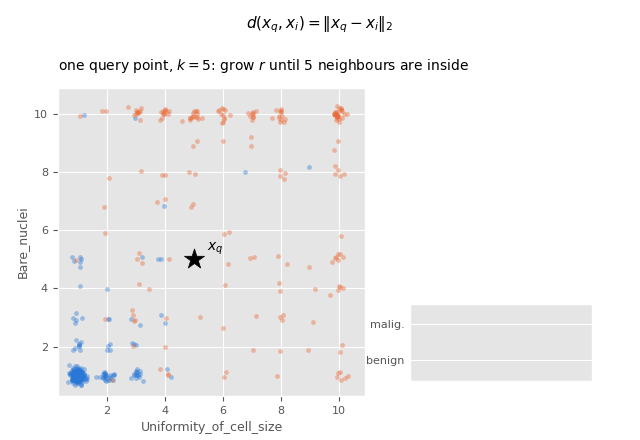

In [ ]:
from IPython.display import Image
Image(filename='../animations/gifs/knn_vote.gif')

point: [5. 5.]
vote: 4 (malignant)  confidence: 0.6

  distance 1.00  label 2
  distance 1.00  label 2
  distance 1.00  label 4
  distance 1.00  label 4
  distance 1.41  label 4


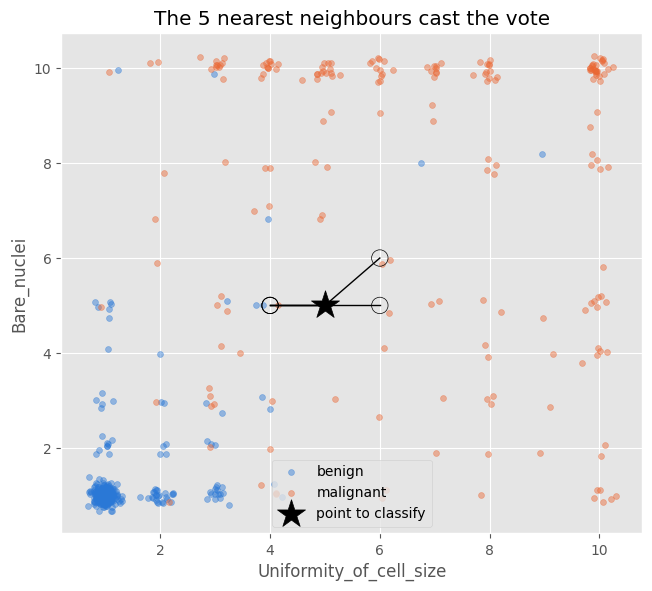

In [6]:
f1, f2 = 1, 5   # uniformity of cell size, bare nuclei

two_d = {}
for group in train_set:
    two_d[group] = [np.array([p[f1], p[f2]]) for p in train_set[group]]

point = np.array([test_set[4][3][f1], test_set[4][3][f2]])

# find the 5 nearest training points to it
distances = []
for group in two_d:
    for features in two_d[group]:
        distances.append([np.linalg.norm(features - point), group, features])
nearest = sorted(distances, key=lambda d: d[0])[:5]

vote, confidence = k_nearest_neighbors(two_d, point, k=5)
print('point:', point)
print('vote:', vote, '(benign)' if vote == 2 else '(malignant)', ' confidence:', confidence)
print()
for d, group, features in nearest:
    print(f'  distance {d:.2f}  label {group}')

jitter = np.random.default_rng(1)
plt.figure(figsize=(7.5, 6.5))

for group, color, name in [(2, benign_color, 'benign'), (4, malignant_color, 'malignant')]:
    pts = np.array(two_d[group]) + jitter.normal(0, 0.12, (len(two_d[group]), 2))
    plt.scatter(pts[:, 0], pts[:, 1], color=color, s=18, alpha=0.45, label=name)

for d, group, features in nearest:
    plt.plot([point[0], features[0]], [point[1], features[1]], color='k', linewidth=1)
    plt.scatter(features[0], features[1], facecolors='none', edgecolors='k', s=140)

plt.scatter(point[0], point[1], color='k', marker='*', s=450, label='point to classify')

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title('The 5 nearest neighbours cast the vote')
plt.legend()
plt.show()

## The decision boundary

Running the same vote across a grid of points shows which label KNN would give anywhere on the
plane. The cell classifies every point on a 45 x 45 grid using the same two measurements and
shades the background by the result.

The boundary is not a straight line. KNN never fits one - the shape falls out of wherever the
training points happen to sit, which is why it can follow an irregular split that a straight-line
model could not.

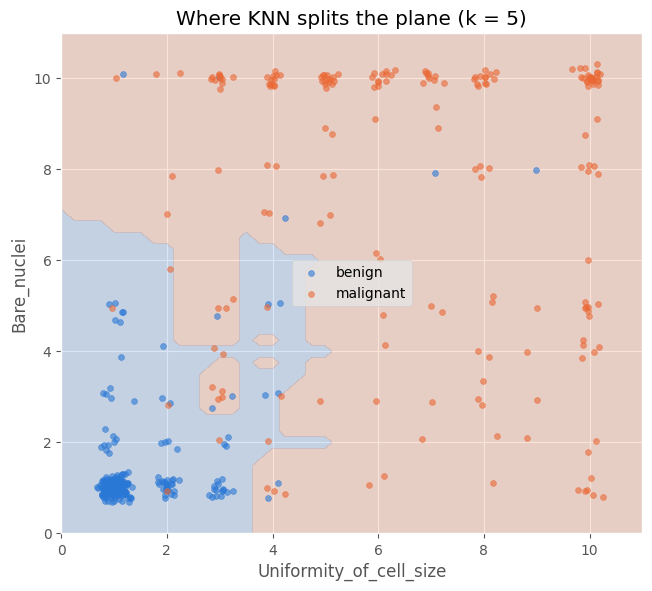

In [7]:
grid = np.linspace(0, 11, 45)
zone = np.zeros((len(grid), len(grid)))

for i, a in enumerate(grid):
    for j, b in enumerate(grid):
        vote, _ = k_nearest_neighbors(two_d, [a, b], k=5)
        zone[j, i] = vote

plt.figure(figsize=(7.5, 6.5))
plt.contourf(grid, grid, zone, levels=[1, 3, 5],
             colors=[benign_color, malignant_color], alpha=0.18)

for group, color, name in [(2, benign_color, 'benign'), (4, malignant_color, 'malignant')]:
    pts = np.array(two_d[group]) + jitter.normal(0, 0.12, (len(two_d[group]), 2))
    plt.scatter(pts[:, 0], pts[:, 1], color=color, s=18, alpha=0.6, label=name)

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title('Where KNN splits the plane (k = 5)')
plt.legend()
plt.show()

## Accuracy at different k

$k$ is the one setting KNN has. The cell reruns the whole test set for a range of values and
records the accuracy each time.

At $k = 1$ the prediction is just

$$\hat{y} = y_{i^*}, \qquad i^* = \arg\min_i d(x, x_i)$$

so a single mislabelled or unusual training point decides the answer outright, with nothing to
outvote it. Raising $k$ averages over more neighbours and smooths that out.

Raising it too far has the opposite problem. As $k \to n$ the neighbour set becomes the whole
training set and the prediction collapses to the most common label overall,

$$\hat{y} \to \arg\max_c \sum_{i=1}^{n} \mathbb{1}[\, y_i = c \,]$$

which ignores $x$ completely. The useful values sit between those two failures.

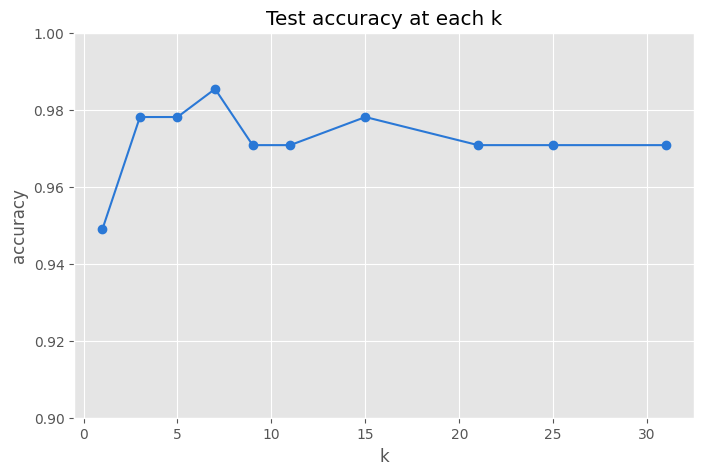

k=1: accuracy 0.9489
k=3: accuracy 0.9781
k=5: accuracy 0.9781
k=7: accuracy 0.9854
k=9: accuracy 0.9708
k=11: accuracy 0.9708
k=15: accuracy 0.9781
k=21: accuracy 0.9708
k=25: accuracy 0.9708
k=31: accuracy 0.9708


In [8]:
ks = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31]
accuracies = []

for k in ks:
    correct = 0
    total = 0
    for group in test_set:
        for data in test_set[group]:
            vote, confidence = k_nearest_neighbors(train_set, data, k=k)
            if group == vote:
                correct += 1
            total += 1
    accuracies.append(correct / total)

plt.figure(figsize=(8, 5))
plt.plot(ks, accuracies, marker='o', color=benign_color)
plt.xlabel('k')
plt.ylabel('accuracy')
plt.ylim(0.9, 1.0)
plt.title('Test accuracy at each k')
plt.show()

for k, a in zip(ks, accuracies):
    print(f'k={k}: accuracy {a:.4f}')

## Where the mistakes are

The cell classifies the test set once more at `k=5` and counts the four outcomes. On this dataset
the distinction that matters is the bottom-left number: a malignant sample called benign is the
expensive error.

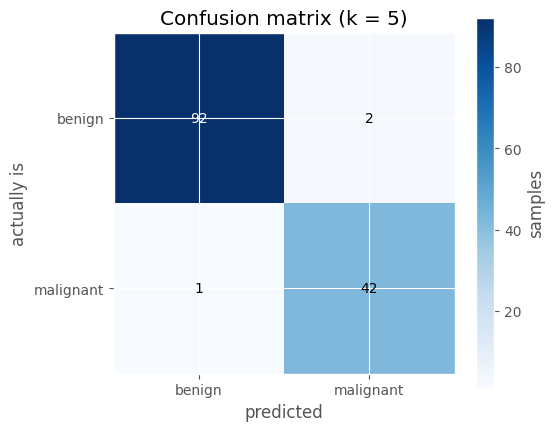

benign called malignant: 2
malignant called benign: 1


In [9]:
table = np.zeros((2, 2), dtype=int)
labels = [2, 4]

for i, group in enumerate(labels):
    for data in test_set[group]:
        vote, _ = k_nearest_neighbors(train_set, data, k=5)
        table[i, labels.index(vote)] += 1

names = ['benign', 'malignant']

plt.figure(figsize=(5.5, 4.8))
plt.imshow(table, cmap='Blues')
for i in range(2):
    for j in range(2):
        plt.text(j, i, table[i, j], ha='center', va='center',
                 color='white' if table[i, j] > table.max() / 2 else 'black')
plt.xticks(range(2), names)
plt.yticks(range(2), names)
plt.xlabel('predicted')
plt.ylabel('actually is')
plt.title('Confusion matrix (k = 5)')
plt.colorbar(label='samples')
plt.show()

print('benign called malignant:', table[0, 1])
print('malignant called benign:', table[1, 0])

## Summary

- KNN has no training step. The stored data is the model, and the work happens when a prediction
  is requested.
- A prediction is three operations: measure the distance to every training point, keep the `k`
  smallest, take the majority label.
- On the Breast Cancer Wisconsin data it reaches **97.8%** at `k = 5`, and **98.5%** at `k = 7`.
- `k = 1` is the weakest setting at **94.9%**, because it copies its answer from a single
  neighbour with nothing to outvote it.
- Because there is no fitted boundary, the split follows the shape of the data rather than a
  straight line.